Initializing Marine Heatwave (MHW) Detection Pipeline...
Calculating daily climatological mean and 90th percentile threshold...
Detected 1 distinct Marine Heatwave events in 30-year record.


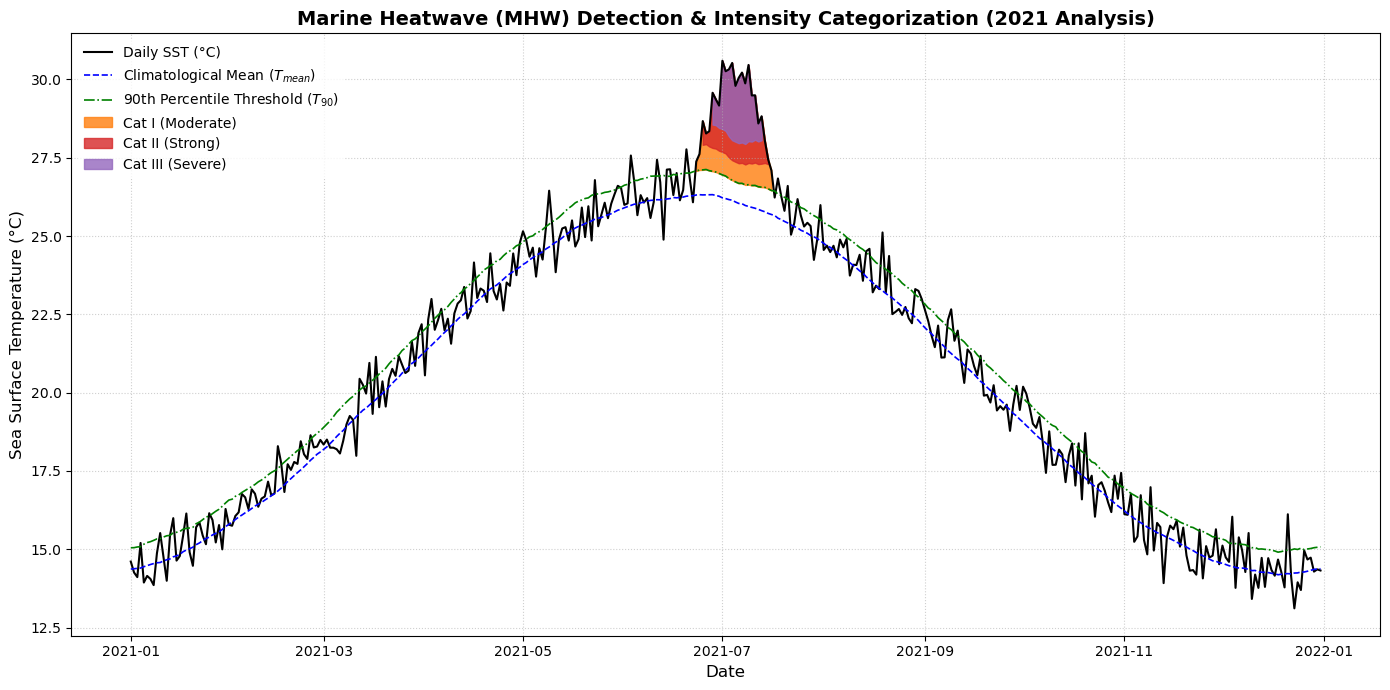

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

print("Initializing Marine Heatwave (MHW) Detection Pipeline...")

# Creating a 30-year daily date range (1993 to 2022)
dates = pd.date_range(start="1993-01-01", end="2022-12-31", freq="D")
n_days = len(dates)

# Base Seasonal Cycle (Sinusoidal variation between 14°C and 26°C)
doy = dates.dayofyear.values
seasonal_cycle = 20.0 + 6.0 * np.sin(2 * np.pi * (doy - 80) / 365.25)

# Long-term Ocean Warming Trend (+0.015°C / year)
years = (dates - dates[0]).days / 365.25
warming_trend = 0.015 * years

# High-frequency Random Noise
np.random.seed(42)
noise = np.random.normal(0, 0.6, size=n_days)

# Inject Extreme Heatwave Event in Summer 2021 (Day 10400 to 10430 approx)
extreme_event_mask = (dates >= "2021-06-15") & (dates <= "2021-07-25")
injected_anomaly = np.zeros(n_days)
injected_anomaly[extreme_event_mask] = 4.2 * np.exp(-((np.arange(np.sum(extreme_event_mask)) - 20)**2) / 100.0)

# Total Simulated SST
sst_values = seasonal_cycle + warming_trend + noise + injected_anomaly

# Create Pandas Series
sst_df = pd.DataFrame({"date": dates, "doy": doy, "sst": sst_values}).set_index("date")

# Group by Day of Year (DOY 1 to 366) to get baseline statistics
clim_mean = sst_df.groupby("doy")["sst"].transform("mean")
clim_p90 = sst_df.groupby("doy")["sst"].transform(lambda x: np.percentile(x, 90))

# Smooth the baseline threshold using an 11-day rolling window
sst_df["clim_mean"] = clim_mean.rolling(11, center=True, min_periods=1).mean()
sst_df["threshold_p90"] = clim_p90.rolling(11, center=True, min_periods=1).mean()
sst_df["anomaly"] = sst_df["sst"] - sst_df["clim_mean"]

# Detecting Marine Heatwave Events (Exceeding P90 for >= 5 consecutive days)
sst_df["is_above_p90"] = sst_df["sst"] > sst_df["threshold_p90"]

# Grouping consecutive True values
sst_df["event_id"] = (sst_df["is_above_p90"] != sst_df["is_above_p90"].shift()).cumsum()
sst_df["event_id"] = np.where(sst_df["is_above_p90"], sst_df["event_id"], np.nan)

# Filtering events with duration >= 5 days
event_durations = sst_df.groupby("event_id")["sst"].count()
mhw_event_ids = event_durations[event_durations >= 5].index

sst_df["is_mhw"] = sst_df["event_id"].isin(mhw_event_ids)

print(f"Detected {len(mhw_event_ids)} distinct Marine Heatwave events in 30-year record.")

# Zoom into 2021 for Detailed Visualization & Categorization
subset_2021 = sst_df.loc["2021-01-01":"2021-12-31"]

# Computing Category Bands: delta_T = Threshold_P90 - Clim_Mean
delta_T = subset_2021["threshold_p90"] - subset_2021["clim_mean"]
cat1_thresh = subset_2021["threshold_p90"]                  # Category I: Moderate
cat2_thresh = subset_2021["threshold_p90"] + 1 * delta_T    # Category II: Strong
cat3_thresh = subset_2021["threshold_p90"] + 2 * delta_T    # Category III: Severe
cat4_thresh = subset_2021["threshold_p90"] + 3 * delta_T    # Category IV: Extreme

# Plotting Publication-Quality MHW Hydrograph
fig, ax = plt.subplots(figsize=(14, 7))

# Ploting SST, Climatological Mean, and 90th Percentile Threshold
ax.plot(subset_2021.index, subset_2021["sst"], color="black", linewidth=1.5, label="Daily SST (°C)")
ax.plot(subset_2021.index, subset_2021["clim_mean"], color="blue", linestyle="--", linewidth=1.2, label=r"Climatological Mean ($T_{mean}$)")
ax.plot(subset_2021.index, subset_2021["threshold_p90"], color="green", linestyle="-.", linewidth=1.2, label=r"90th Percentile Threshold ($T_{90}$)")

# Shading Marine Heatwave Intensity Bands (Hobday et al., 2018)
mhw_mask = subset_2021["is_mhw"]
ax.fill_between(
    subset_2021.index, subset_2021["threshold_p90"], np.maximum(subset_2021["sst"], subset_2021["threshold_p90"]),
    where=mhw_mask, color="#ff7f0e", alpha=0.8, label="Cat I (Moderate)"
)
ax.fill_between(
    subset_2021.index, cat2_thresh, np.maximum(subset_2021["sst"], cat2_thresh),
    where=mhw_mask & (subset_2021["sst"] > cat2_thresh), color="#d62728", alpha=0.8, label="Cat II (Strong)"
)
ax.fill_between(
    subset_2021.index, cat3_thresh, np.maximum(subset_2021["sst"], cat3_thresh),
    where=mhw_mask & (subset_2021["sst"] > cat3_thresh), color="#9467bd", alpha=0.8, label="Cat III (Severe)"
)

# Formatting
ax.set_title("Marine Heatwave (MHW) Detection & Intensity Categorization (2021 Analysis)", fontsize=14, fontweight="bold")
ax.set_ylabel("Sea Surface Temperature (°C)", fontsize=12)
ax.set_xlabel("Date", fontsize=12)
ax.grid(True, linestyle=":", alpha=0.6)
ax.legend(loc="upper left", frameon=True, facecolor="white", edgecolor="none")

plt.tight_layout()
plt.savefig("../figures/marine_heatwave_detection.png", dpi=300, bbox_inches="tight")
plt.show()